# Purpose

This script is an implementation of SHAP (SHapley Additive exPlanations) for the model. 

### Modules

In [1]:
import os
import pandas as pd
import shap
import importlib
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

shap.initjs()

/Users/steeleb/miniconda3/envs/env_TLS_DSS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Custom Modules

In [2]:
def import_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module
# import custom modules
fun_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/functions/"

import_from_path("universals", os.path.join(fun_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test

### Load data and models

First, we'll load in the training sets

In [3]:
data_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/"

all_files = pd.Series(os.listdir(data_dir))
training = all_files[all_files.str.contains('training')]

# these files end up in no particular order, so we need to sort them
training = training.sort_values()

def load_data(file):
    return pd.read_csv(os.path.join(data_dir, file), sep=',')

train1 = load_data(training.values[0])
train2 = load_data(training.values[1])
train3 = load_data(training.values[2])
train4 = load_data(training.values[3])


In [4]:
drop_cols = ['total_solar_radiation_m2', 'mean_rel_hum_m2', 
       'pump_cfs_m2', 'pump_cfs_m3', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m2', 'chipmunk_cfs_m3', 'chipmunk_cfs_m4']

train1 = train1.drop(columns = drop_cols)

train2 = train2.drop(columns = drop_cols)

train3 = train3.drop(columns = drop_cols)

train4 = train4.drop(columns = drop_cols)

And we need to process these for ML-ready format. Since we're only using the training data, we can use the get_features_labels_test function

In [5]:
features_1, labels_1 = twotemp_labels_features_test(train1)
features_2, labels_2 = twotemp_labels_features_test(train2)
features_3, labels_3 = twotemp_labels_features_test(train3)
features_4, labels_4 = twotemp_labels_features_test(train4)


And the pickle files for each of the models

In [6]:
model_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/tiny_model/dump/five_ten/"

models = [f for f in os.listdir(model_dir) if 'history' not in f]

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


### Model 1

In [7]:
explainer_1 = shap.Explainer(model_1, pd.DataFrame.to_numpy(features_1))
shap_values_1 = explainer_1.shap_values(features_1)

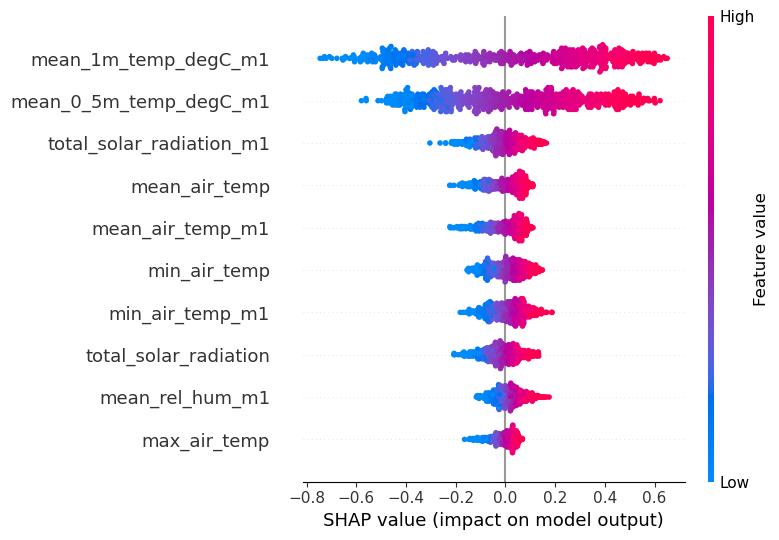

In [8]:
shap_1_1m = (shap.summary_plot(shap_values_1[:, :, 0], 
                            pd.DataFrame.to_numpy(features_1), 
                            max_display=10, 
                            feature_names = features_1.columns, 
                            show=False)
)


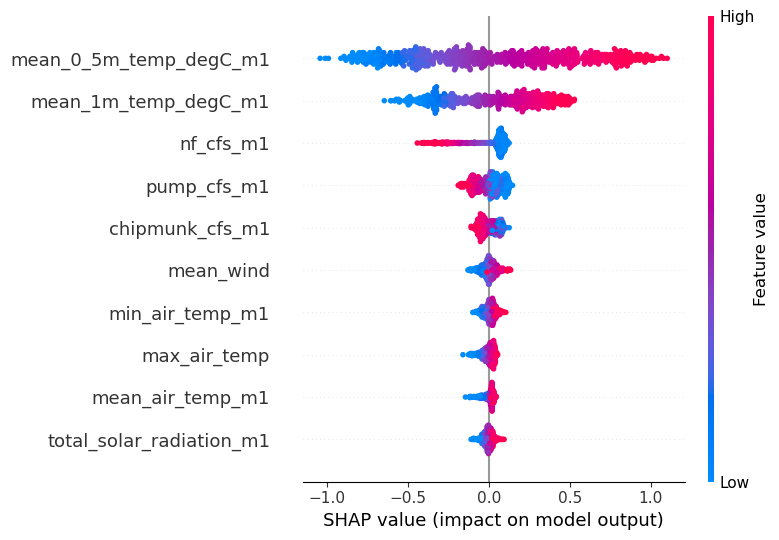

In [9]:

shap_1_int = (shap.summary_plot(shap_values_1[:, :, 1], 
                            pd.DataFrame.to_numpy(features_1), 
                            max_display=10, 
                            feature_names = features_1.columns, 
                            show=False)
)

## Model 2

In [10]:
explainer_2 = shap.Explainer(model_2, pd.DataFrame.to_numpy(features_2))
shap_values_2 = explainer_2.shap_values(features_2)

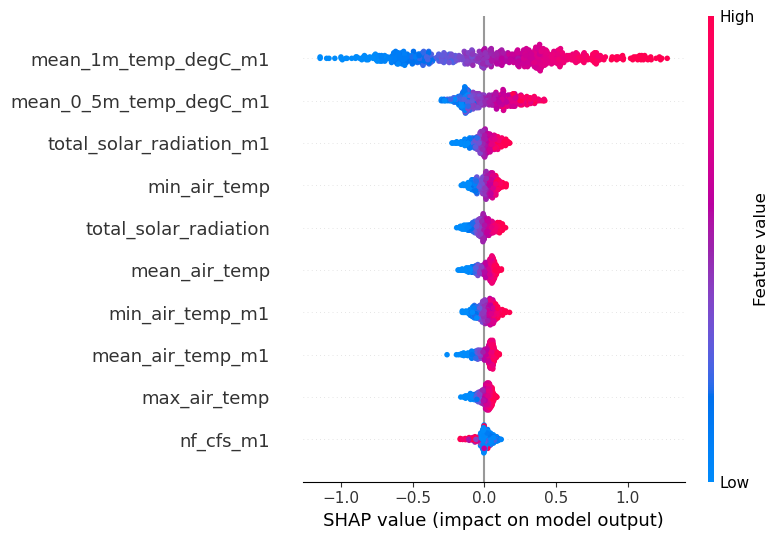

In [11]:
shap_2_1m = (shap.summary_plot(shap_values_2[:, :, 0], 
                            pd.DataFrame.to_numpy(features_2), 
                            max_display=10, 
                            feature_names = features_2.columns, 
                            show=False)
)

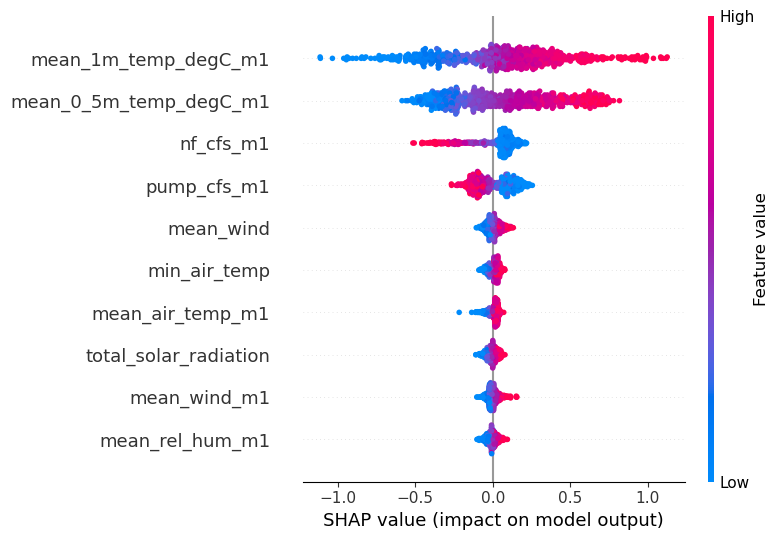

In [12]:
shap_2_int = (shap.summary_plot(shap_values_2[:, :, 1], 
                            pd.DataFrame.to_numpy(features_2), 
                            max_display=10, 
                            feature_names = features_2.columns, 
                            show=False)
)

# Model 3

In [13]:
explainer_3 = shap.Explainer(model_3, pd.DataFrame.to_numpy(features_3))
shap_values_3 = explainer_3.shap_values(features_3)

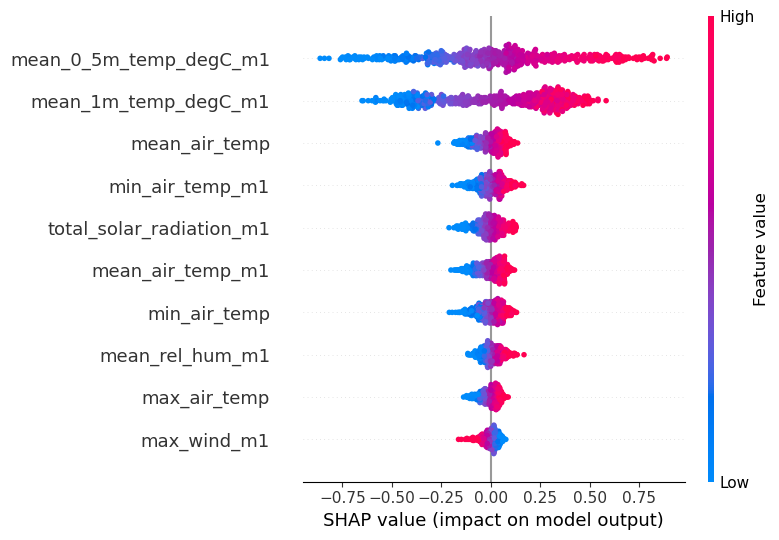

In [14]:
shap_3_1m = (shap.summary_plot(shap_values_3[:, :, 0],
                            pd.DataFrame.to_numpy(features_3), 
                            max_display=10, 
                            feature_names = features_3.columns, 
                            show=False)
)

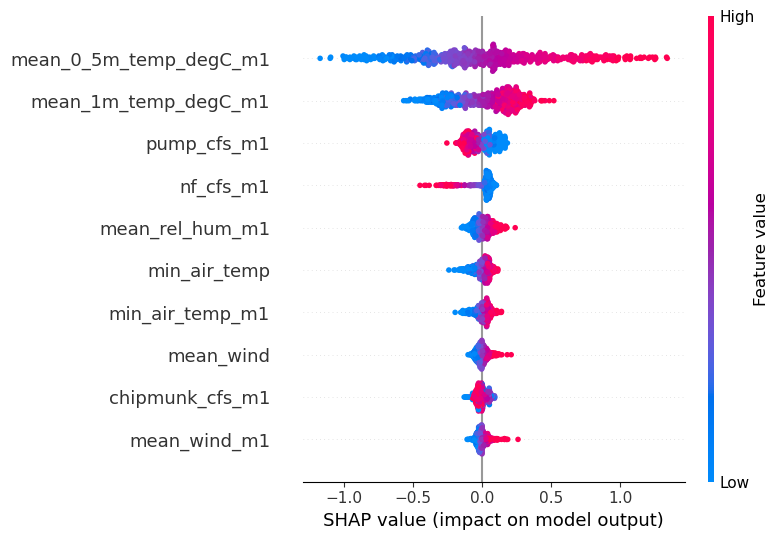

In [15]:
shap_3_int = (shap.summary_plot(shap_values_3[:, :, 1],
                            pd.DataFrame.to_numpy(features_3), 
                            max_display=10, 
                            feature_names = features_3.columns, 
                            show=False)
)

# Model 4

In [16]:
explainer_4 = shap.Explainer(model_4, pd.DataFrame.to_numpy(features_4))
shap_values_4 = explainer_4.shap_values(features_4)

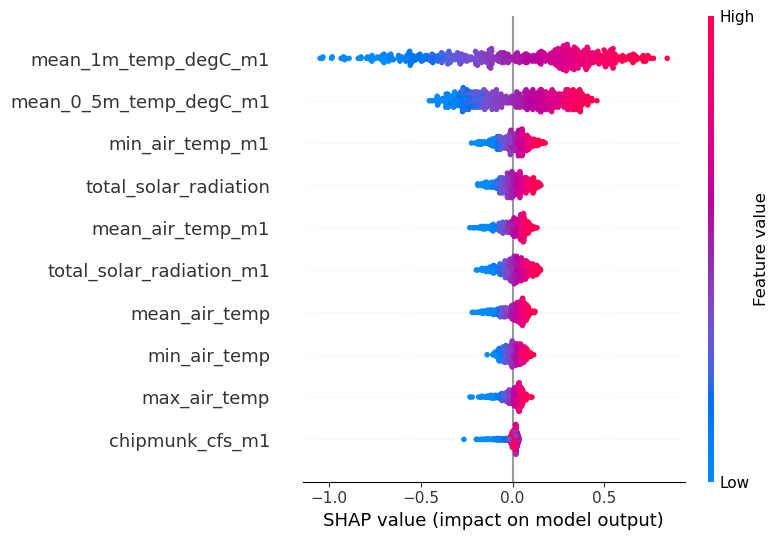

In [17]:
shap_4_1m = (shap.summary_plot(shap_values_4[:, :, 0],
                            pd.DataFrame.to_numpy(features_4), 
                            max_display=10, 
                            feature_names = features_4.columns, 
                            show=False)
)

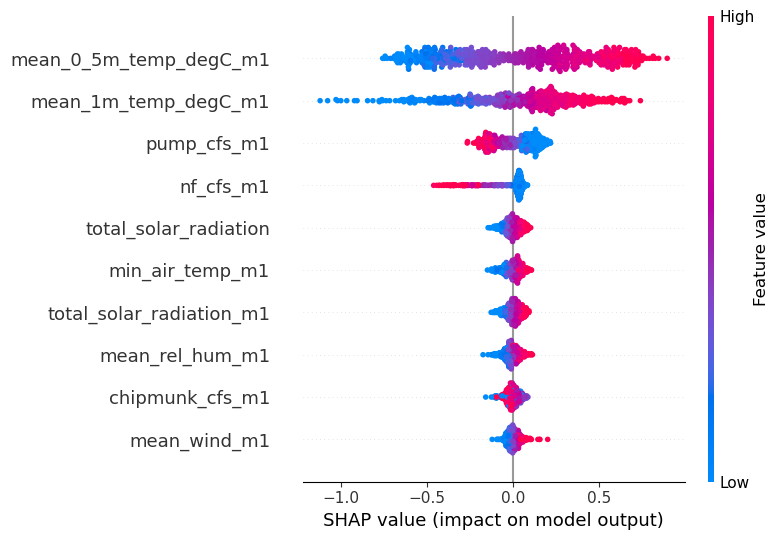

In [18]:
shape_4_int = (shap.summary_plot(shap_values_4[:, :, 1],
                            pd.DataFrame.to_numpy(features_4), 
                            max_display=10, 
                            feature_names = features_4.columns, 
                            show=False)
)

This all looks good to go. We can now see how this all looks in the test set.